### Assignment 4
**Recurrent Neural Network (RNN)**: Use the Google stock prices dataset and design a time series analysis and prediction system using RNN.

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [62]:
# load the dataset
df = pd.read_csv('Google_Stock.csv', thousands=',')


In [63]:
print("Shape of data: ",df.shape)

Shape of data:  (4431, 7)


In [64]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2004-08-19,50.050049,52.082081,48.028027,50.220219,50.220219,44659096
1,2004-08-20,50.555557,54.594597,50.300301,54.209209,54.209209,22834343
2,2004-08-23,55.430431,56.796799,54.579578,54.754753,54.754753,18256126
3,2004-08-24,55.675674,55.855858,51.836838,52.487488,52.487488,15247337
4,2004-08-25,52.532532,54.054054,51.991993,53.053055,53.053055,9188602


In [65]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4431 entries, 0 to 4430
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       4431 non-null   str    
 1   Open       4431 non-null   float64
 2   High       4431 non-null   float64
 3   Low        4431 non-null   float64
 4   Close      4431 non-null   float64
 5   Adj Close  4431 non-null   float64
 6   Volume     4431 non-null   int64  
dtypes: float64(5), int64(1), str(1)
memory usage: 242.4 KB


In [66]:
df.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

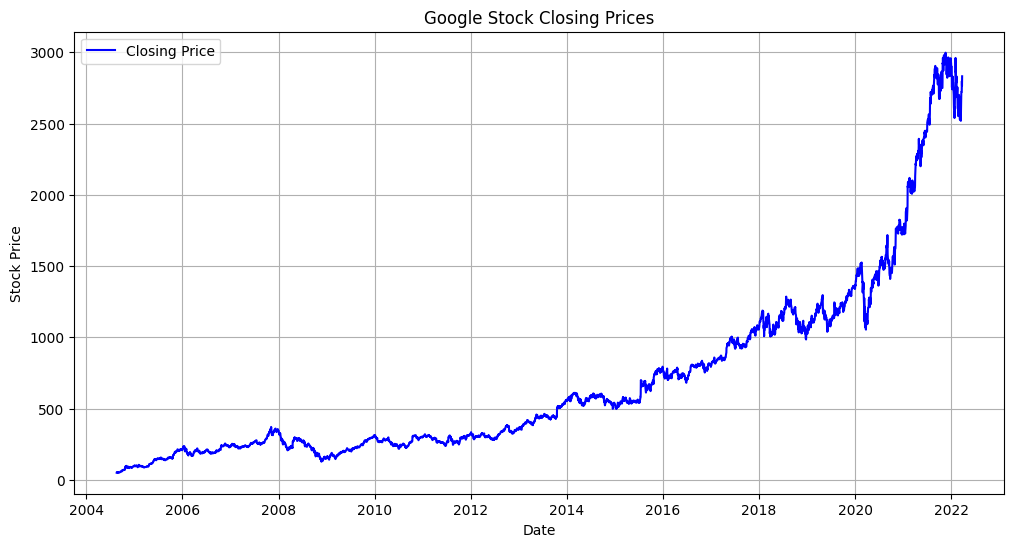

In [67]:
# convert date column
df['Date'] = pd.to_datetime(df['Date'])

plt.figure(figsize=(12,6))

plt.plot(df['Date'], df['Close'],
         color='blue',
         label='Closing Price')

plt.title("Google Stock Closing Prices")
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.legend()

plt.grid(True)

plt.show()

In [68]:
# select only features, not date
data = df.drop('Date', axis=1)

In [69]:
# Scale data
scaler = MinMaxScaler()
close = df[['Close']].values
scaled = scaler.fit_transform(close)
# Train-test split
split = int(len(scaled) * 0.8)
train, test = scaled[:split], scaled[split:]

In [70]:
# Create sequences
def create_dataset(data, step=4):
    X, y = [], []
    for i in range(len(data) - step):
        X.append(data[i:i+step])
        y.append(data[i+step])
    return np.array(X), np.array(y)

x_train, y_train = create_dataset(train)
x_test, y_test = create_dataset(test)

In [71]:
# Build model
model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(x_train.shape[1], 1)),
    LSTM(32),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

/home/naveed-malik/myenv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [72]:
# train the model
history = model.fit(
    x_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split = 0.2,
    verbose = 1
)

Epoch 1/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0010 - val_loss: 5.0256e-05
Epoch 2/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.0991e-05 - val_loss: 1.1606e-04
Epoch 3/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.0749e-05 - val_loss: 5.8366e-05
Epoch 4/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.1232e-05 - val_loss: 6.8765e-05
Epoch 5/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.1012e-05 - val_loss: 6.8077e-05
Epoch 6/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.1102e-05 - val_loss: 4.9117e-05
Epoch 7/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.1084e-05 - val_loss: 5.7567e-05
Epoch 8/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.1435e-05 - val_loss: 1.0056e-04
Epoch 9/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.2378e-05 - val_loss: 4.9953e-05
Epoch 10/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.1319e-05 - val_loss: 4.8283e-05
Epoch 11/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.0950e-05 - val_los

In [74]:
#Model loss and accuracy
loss = model.evaluate(x_test,y_test)
print("Model loss: ",loss)


28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.2869e-04
Model loss:  0.00022868718951940536


In [75]:
# Predict and inverse scale
y_pred = model.predict(x_test)

y_pred = scaler.inverse_transform(y_pred)
y_test = scaler.inverse_transform(y_test)

28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


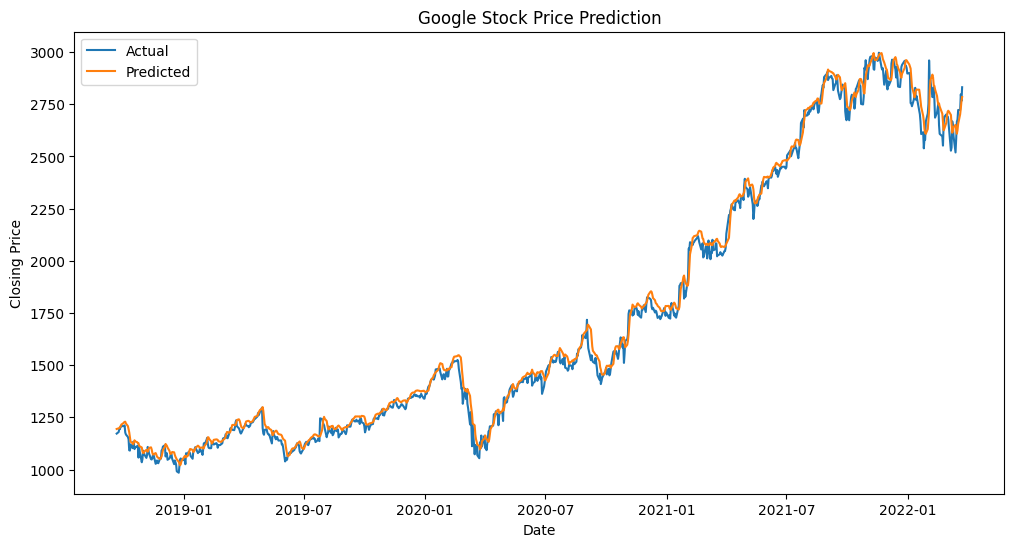

In [76]:
plt.figure(figsize=(12,6))
dates = pd.to_datetime(df['Date']).iloc[len(df) - len(y_test):]

plt.plot(dates, y_test, label="Actual")
plt.plot(dates, y_pred, label="Predicted")

plt.title("Google Stock Price Prediction")

plt.xlabel("Date")
plt.ylabel("Closing Price")

plt.legend()

plt.show()

In [77]:
# Metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('RMSE: ', rmse)
print('MAE: ', mae)
print('R2 Score: ', r2)

RMSE:  44.56142196034651
MAE:  32.86791425993594
R2 Score:  0.9951158755654501


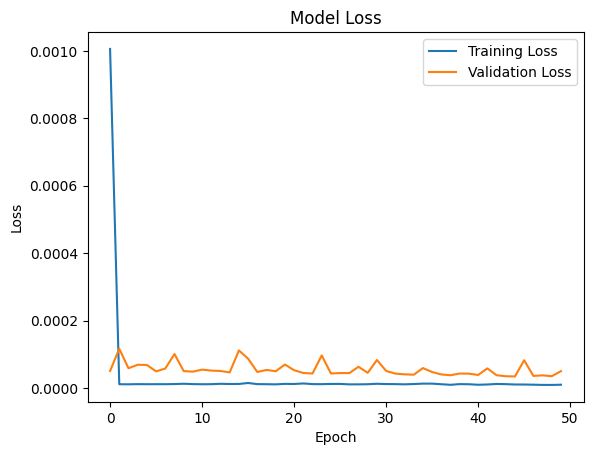

In [78]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()